In [10]:
import lightgbm as lgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import polars as pl
from datetime import datetime
import numpy as np
import optuna

In [2]:
from pathlib import Path
path = Path.cwd()
if not Path(path, "data").exists(): path = path.parent

## Prueba con datos básicos de coordenadas, desplazamiento, fecha...

In [56]:
df = pl.read_parquet(path / "data" / "datos_tip_num.parquet")

In [ ]:
df = df.filter(pl.col("payment_type") != 2) # Quitamos pagos en efectivo

In [58]:
df.collect_schema()

Schema([('pickup_datetime', Datetime(time_unit='us', time_zone=None)),
        ('PULocationID', Int16),
        ('DOLocationID', Int16),
        ('tip_amount', Int16),
        ('payment_type', Int8),
        ('VendorID', Int8),
        ('PUis_airport', Int8),
        ('DOis_airport', Int8),
        ('pickup_latitude', Float64),
        ('pickup_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('pickup_dist_nyc', Float64),
        ('dropoff_dist_nyc', Float64),
        ('pickup_dist_chp', Float64),
        ('dropoff_dist_chp', Float64),
        ('pickup_dist_exp', Float64),
        ('dropoff_dist_exp', Float64),
        ('month', Int8),
        ('dayofyear', Int16),
        ('weekday', Int8),
        ('hour', Float64),
        ('distance', Float64),
        ('direction', Float64),
        ('adj_dist', Float64)])

In [61]:
categorical_cols = ["payment_type", "VendorID", "PUis_airport", "DOis_airport", "weekday", "month"]#, "lluvia_flag"]
input_cols = [col for col in df.columns if col not in ['Date', 'pickup_datetime', 'PULocationID', 'DOLocationID', 'tip_amount']]

split_val = datetime(2025, 10, 1)
split_test = datetime(2025,11,1)
df_train = df.filter(pl.col("pickup_datetime") < split_val)
df_val = df.filter((pl.col("pickup_datetime") >= split_val) & (pl.col("pickup_datetime") < split_test))
df_test = df.filter(pl.col("pickup_datetime") >= split_val)

x_train, y_train = df_train.select(input_cols), df_train.select("tip_amount").to_numpy()
x_test, y_test = df_test.select(input_cols), df_test.select("tip_amount").to_numpy()
x_val, y_val = df_val.select(input_cols), df_val.select("tip_amount").to_numpy()

In [62]:
nombres_columnas = x_train.columns 

train_data = lgb.Dataset(
    data=x_train, 
    label=y_train, 
    feature_name=nombres_columnas,
    categorical_feature=categorical_cols,
    free_raw_data=False
)

val_data = lgb.Dataset(
    data=x_val, 
    label=y_val, 
    reference=train_data,
    feature_name=nombres_columnas
)

lgbm_params = {
    'objective': 'tweedie',
    'boosting': 'gbdt',
    'max_bin': 255,
    'metric': 'rmse',
    'verbose': -1,
    'tweedie_variance_power': 1.5736005740734198,
    'learning_rate': 0.010469439266335008,
    'num_leaves': 268,
    'max_depth': 12,
    'min_data_in_leaf': 702,
    'feature_fraction': 0.6035669550945819,
    'bagging_fraction': 0.979833460020387,
    'bagging_freq': 4,
}

model_lgb = lgb.train(
    params=lgbm_params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    valid_names=['Entrenamiento', 'Validacion'],
    
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


Training until validation scores don't improve for 50 rounds
[100]	Entrenamiento's rmse: 288.63	Validacion's rmse: 315.732
[200]	Entrenamiento's rmse: 273.479	Validacion's rmse: 301.242
[300]	Entrenamiento's rmse: 268.476	Validacion's rmse: 295.882
[400]	Entrenamiento's rmse: 267.037	Validacion's rmse: 294.116
[500]	Entrenamiento's rmse: 266.462	Validacion's rmse: 293.436
[600]	Entrenamiento's rmse: 266.138	Validacion's rmse: 293.083
[700]	Entrenamiento's rmse: 265.896	Validacion's rmse: 292.855
[800]	Entrenamiento's rmse: 265.721	Validacion's rmse: 292.711
[900]	Entrenamiento's rmse: 265.571	Validacion's rmse: 292.608
[1000]	Entrenamiento's rmse: 265.441	Validacion's rmse: 292.534
[1100]	Entrenamiento's rmse: 265.327	Validacion's rmse: 292.474
[1200]	Entrenamiento's rmse: 265.227	Validacion's rmse: 292.427
[1300]	Entrenamiento's rmse: 265.135	Validacion's rmse: 292.392
[1400]	Entrenamiento's rmse: 265.041	Validacion's rmse: 292.365
[1500]	Entrenamiento's rmse: 264.949	Validacion's rms

In [ ]:
model_lgb.save_model(path / "data" / "lgbm_rmse292.213_num_bestpar.txt")

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

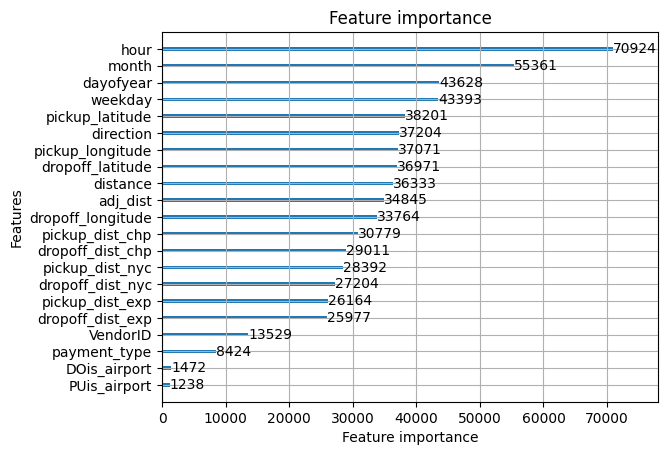

In [32]:
lgb.plot_importance(model_lgb)
# Mejores parámetros: [I 2026-03-22 17:43:31,890] Trial 11 finished with value: 290.5251642434954 and parameters: {'tweedie_variance_power': 1.1188966741749302, 'learning_rate': 0.02912403163132028, 'num_leaves': 403, 'max_depth': 9, 'min_data_in_leaf': 976, 'feature_fraction': 0.6117769967862083, 'bagging_fraction': 0.814624225861981, 'bagging_freq': 3}. Best is trial 11 with value: 290.5251642434954.

In [63]:
def evaluar_modelo(y_true, y_pred, nombre_set="Test"):
    """
    Evalúa predicciones de regresión y devuelve un diccionario con las métricas.
    Soporta entradas como Series de Polars, listas o arrays de NumPy.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    media_real = np.mean(y_true)
    media_pred = np.mean(y_pred)
    
    print(f"\n--- REPORTE DE RENDIMIENTO: {nombre_set} ---")
    print(f"MAE  (Error Absoluto Medio):       {mae:.4f}")
    print(f"RMSE (Raíz del Error Cuadrático):  {rmse:.4f}")
    print(f"R²   (Coef. de Determinación):     {r2:.4f}")
    print("-" * 45)
    print(f"Propina media real del set:        {media_real:.4f}")
    print(f"Propina media predicha:            {media_pred:.4f}")
    print("-" * 45)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Media_Real": media_real,
        "Media_Pred": media_pred
    }

predicciones = model_lgb.predict(x_test)
metricas_finales = evaluar_modelo(y_test, predicciones, nombre_set="Test (Nov-Dic 2025) num optuna")

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Test (Nov-Dic 2025) num optuna ---
MAE  (Error Absoluto Medio):       155.7802
RMSE (Raíz del Error Cuadrático):  288.9312
R²   (Coef. de Determinación):     0.2391
---------------------------------------------
Propina media real del set:        130.9540
Propina media predicha:            119.3941
---------------------------------------------


In [16]:
dataset_params = {
    'max_bin': 255
}

train_data_opt = lgb.Dataset(
    data=x_train, 
    label=y_train, 
    feature_name=nombres_columnas,
    categorical_feature=categorical_cols,
    free_raw_data=False,
    params=dataset_params
)

val_data_opt = lgb.Dataset(
    data=x_val, 
    label=y_val, 
    reference=train_data,
    feature_name=nombres_columnas,
    free_raw_data=False
)

train_data_opt.construct()
val_data_opt.construct()

def objective(trial):
    param = {
        'objective': 'tweedie',
        'boosting': 'gbdt',
        'metric': 'rmse',
        'verbose': -1,
        'random_state': 42,
        
        'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.1, 1.9),
        
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 1000),
        
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),       
    }

    model = lgb.train(
        params=param,
        train_set=train_data_opt,
        num_boost_round=3000,
        valid_sets=[val_data_opt],
        
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False)
        ]
    )
    
    return model.best_score['valid_0']['rmse']


study = optuna.create_study(direction='minimize', study_name="LGBM_Taxis")

# Lanzamos 20 pruebas (trials). Si va rápido, puedes subirlo a 50 o 100.
print("Iniciando optimización con Optuna...")
study.optimize(objective, n_trials=20)

print("\n--- ¡Optimización Terminada! ---")
print(f"Mejor RMSE de Validación: {study.best_value}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")
c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:2535: UserWarning: Overriding the parameters from Reference Dataset.
  _log_warning("Overriding the parameters from Reference Dataset.")
[I 2026-03-22 11:15:20,665] A new study created in memory with name: LGBM_Taxis


Iniciando optimización con Optuna...


[I 2026-03-22 11:18:39,471] Trial 0 finished with value: 290.6185600012942 and parameters: {'tweedie_variance_power': 1.8688264206713663, 'learning_rate': 0.010001799586605015, 'num_leaves': 366, 'max_depth': 15, 'min_data_in_leaf': 845, 'feature_fraction': 0.8017694460973857, 'bagging_fraction': 0.6439930362453063, 'bagging_freq': 5}. Best is trial 0 with value: 290.6185600012942.
[I 2026-03-22 11:20:00,429] Trial 1 finished with value: 290.7282742911731 and parameters: {'tweedie_variance_power': 1.1922447474774622, 'learning_rate': 0.0920187178184183, 'num_leaves': 210, 'max_depth': 5, 'min_data_in_leaf': 119, 'feature_fraction': 0.923696533727945, 'bagging_fraction': 0.9039480673343537, 'bagging_freq': 2}. Best is trial 0 with value: 290.6185600012942.
[I 2026-03-22 11:22:34,067] Trial 2 finished with value: 290.42059133145807 and parameters: {'tweedie_variance_power': 1.2611224457355639, 'learning_rate': 0.024815981264201526, 'num_leaves': 481, 'max_depth': 7, 'min_data_in_leaf': 6


--- ¡Optimización Terminada! ---
Mejor RMSE de Validación: 290.06089407536496
Mejores Hiperparámetros encontrados:
    'tweedie_variance_power': 1.5736005740734198,
    'learning_rate': 0.010469439266335008,
    'num_leaves': 268,
    'max_depth': 12,
    'min_data_in_leaf': 702,
    'feature_fraction': 0.6035669550945819,
    'bagging_fraction': 0.979833460020387,
    'bagging_freq': 4,


## Prueba con más columnas de datos

df = pl.read_parquet(path / "data" / "datos_tip_all.parquet")

In [ ]:
df = df.filter(pl.col("payment_type") != 2)

In [ ]:
categorical_cols = ["payment_type", "VendorID", "PUis_airport", "DOis_airport", "weekday", "month"]#, "lluvia_flag"]
input_cols = [col for col in df.columns if col not in ['Date', 'pickup_datetime', 'PULocationID', 'DOLocationID', 'tip_amount']]

split_val = datetime(2025, 10, 1)
split_test = datetime(2025,11,1)
df_train = df.filter(pl.col("pickup_datetime") < split_val)
df_val = df.filter((pl.col("pickup_datetime") >= split_val) & (pl.col("pickup_datetime") < split_test))
df_test = df.filter(pl.col("pickup_datetime") >= split_val)

x_train, y_train = df_train.select(input_cols), df_train.select("tip_amount").to_numpy()
x_test, y_test = df_test.select(input_cols), df_test.select("tip_amount").to_numpy()
x_val, y_val = df_val.select(input_cols), df_val.select("tip_amount").to_numpy()

In [53]:
nombres_columnas = x_train.columns 

train_data = lgb.Dataset(
    data=x_train, 
    label=y_train, 
    feature_name=nombres_columnas,
    categorical_feature=categorical_cols,
    free_raw_data=False
)

val_data = lgb.Dataset(
    data=x_val, 
    label=y_val, 
    reference=train_data,
    feature_name=nombres_columnas
)

lgbm_params = {
    'objective': 'tweedie',
    'boosting': 'gbdt',
    'max_bin': 255,
    'metric': 'rmse',
    'verbose': -1,
    'tweedie_variance_power': 1.2971844999716964,
    'learning_rate': 0.04595117783073811,
    'num_leaves': 367,
    'max_depth': 9,
    'min_data_in_leaf': 702,
    'feature_fraction': 0.723804713211151,
    'bagging_fraction': 0.9435948037434145,
    'bagging_freq': 6,
}

model_lgb = lgb.train(
    params=lgbm_params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    valid_names=['Entrenamiento', 'Validacion'],
    
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

Training until validation scores don't improve for 50 rounds
[100]	Entrenamiento's rmse: 265.491	Validacion's rmse: 292.049
[200]	Entrenamiento's rmse: 264.444	Validacion's rmse: 291.084
[300]	Entrenamiento's rmse: 263.875	Validacion's rmse: 290.836
[400]	Entrenamiento's rmse: 263.493	Validacion's rmse: 290.737
[500]	Entrenamiento's rmse: 263.071	Validacion's rmse: 290.658
[600]	Entrenamiento's rmse: 262.744	Validacion's rmse: 290.635
[700]	Entrenamiento's rmse: 262.427	Validacion's rmse: 290.589
[800]	Entrenamiento's rmse: 262.078	Validacion's rmse: 290.578
Early stopping, best iteration is:
[802]	Entrenamiento's rmse: 262.074	Validacion's rmse: 290.574


In [55]:
model_lgb.save_model(path / "data" / "lgbm_rmse290.574_all_bestpar.txt")

In [ ]:
predicciones = model_lgb.predict(x_test)
metricas_finales = evaluar_modelo(y_test, predicciones, nombre_set="Test (Nov-Dic 2025) all")

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Test (Nov-Dic 2025) num optuna ---
MAE  (Error Absoluto Medio):       155.9773
RMSE (Raíz del Error Cuadrático):  287.2493
R²   (Coef. de Determinación):     0.2413
---------------------------------------------
Propina media real del set:        129.7366
Propina media predicha:            122.0958
---------------------------------------------


Mejora el coef. de determinación pero no demasiado

In [52]:
dataset_params = {
    'max_bin': 255
}

train_data_opt = lgb.Dataset(
    data=x_train, 
    label=y_train, 
    feature_name=nombres_columnas,
    categorical_feature=categorical_cols,
    free_raw_data=False,
    params=dataset_params
)

val_data_opt = lgb.Dataset(
    data=x_val, 
    label=y_val, 
    reference=train_data,
    feature_name=nombres_columnas,
    free_raw_data=False
)

train_data_opt.construct()
val_data_opt.construct()

def objective(trial):
    param = {
        'objective': 'tweedie',
        'boosting': 'gbdt',
        'metric': 'rmse',
        'verbose': -1,
        'random_state': 42,
        
        'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.1, 1.9),
        
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 1000),
        
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),       
    }

    model = lgb.train(
        params=param,
        train_set=train_data_opt,
        num_boost_round=3000,
        valid_sets=[val_data_opt],
        
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False)
        ]
    )
    
    return model.best_score['valid_0']['rmse']


study = optuna.create_study(direction='minimize', study_name="LGBM_Taxis")

# Lanzamos 20 pruebas (trials). Si va rápido, puedes subirlo a 50 o 100.
print("Iniciando optimización con Optuna...")
study.optimize(objective, n_trials=20)

print("\n--- ¡Optimización Terminada! ---")
print(f"Mejor RMSE de Validación: {study.best_value}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-03-22 18:48:51,694] A new study created in memory with name: LGBM_Taxis


Iniciando optimización con Optuna...


[I 2026-03-22 18:49:51,613] Trial 0 finished with value: 290.9830324008238 and parameters: {'tweedie_variance_power': 1.605569248103551, 'learning_rate': 0.087068613764971, 'num_leaves': 199, 'max_depth': 14, 'min_data_in_leaf': 524, 'feature_fraction': 0.9289726409357716, 'bagging_fraction': 0.8360615327415173, 'bagging_freq': 4}. Best is trial 0 with value: 290.9830324008238.
[I 2026-03-22 18:54:12,537] Trial 1 finished with value: 290.93700520400296 and parameters: {'tweedie_variance_power': 1.3969381655551072, 'learning_rate': 0.020377088738147715, 'num_leaves': 43, 'max_depth': 13, 'min_data_in_leaf': 473, 'feature_fraction': 0.7067476943490514, 'bagging_fraction': 0.7310067402199839, 'bagging_freq': 1}. Best is trial 1 with value: 290.93700520400296.
[I 2026-03-22 18:59:10,675] Trial 2 finished with value: 291.4677957207271 and parameters: {'tweedie_variance_power': 1.3553056736506133, 'learning_rate': 0.013772574331873825, 'num_leaves': 176, 'max_depth': 5, 'min_data_in_leaf': 6


--- ¡Optimización Terminada! ---
Mejor RMSE de Validación: 290.50428433893444
Mejores Hiperparámetros encontrados:
    'tweedie_variance_power': 1.2971844999716964,
    'learning_rate': 0.04595117783073811,
    'num_leaves': 367,
    'max_depth': 9,
    'min_data_in_leaf': 702,
    'feature_fraction': 0.723804713211151,
    'bagging_fraction': 0.9435948037434145,
    'bagging_freq': 6,


lgbm_params = { 
    'objective': 'tweedie',
    'boosting': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 1200,
    'max_depth': -1,
    'max_bin': 5000,
    'metric': 'rmse',
    'verbose': -1
}

Validacion rmse: 290.744
--- REPORTE DE RENDIMIENTO: Test (Nov-Dic 2025) ---
MAE  (Error Absoluto Medio):       153.3985
RMSE (Raíz del Error Cuadrático):  287.9860
R²   (Coef. de Determinación):     0.2388
---------------------------------------------
Propina media real del set:        129.8833
Propina media predicha:            116.4806
---------------------------------------------

Datos cnn solo
Validacion rmse: 290.608
--- REPORTE DE RENDIMIENTO: Test (Nov-Dic 2025) ---
MAE  (Error Absoluto Medio):       153.9865
RMSE (Raíz del Error Cuadrático):  287.8091
R²   (Coef. de Determinación):     0.2397
---------------------------------------------
Propina media real del set:        129.8833
Propina media predicha:            118.7134
---------------------------------------------

Con lluvia
290.763
--- REPORTE DE RENDIMIENTO: Test (Nov-Dic 2025) ---
MAE  (Error Absoluto Medio):       153.4985
RMSE (Raíz del Error Cuadrático):  288.0203
R²   (Coef. de Determinación):     0.2386
---------------------------------------------
Propina media real del set:        129.8833
Propina media predicha:            116.5257
---------------------------------------------


Sin codificar con seno, coseno
290.419
--- REPORTE DE RENDIMIENTO: Test (Nov-Dic 2025) ---
MAE  (Error Absoluto Medio):       154.3491
RMSE (Raíz del Error Cuadrático):  287.7171
R²   (Coef. de Determinación):     0.2402
---------------------------------------------
Propina media real del set:        129.8833
Propina media predicha:            120.0661
---------------------------------------------